In [ ]:
# Cek GPU dan Environment
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU tersedia:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU tidak ada, pakai CPU")
device

GPU tersedia: Tesla T4


device(type='cuda')

In [ ]:
# Install library
!pip install -U transformers
!pip install contractions
!pip install bs4
!pip install nltk

# Download stopwords NLTK
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Load Dataset
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename)
df.head()

Saving gold-dataset-sinha-khandait.csv to gold-dataset-sinha-khandait.csv


,Dates,URL,News,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,Price Sentiment
0,28-01-2016,http://www.marketwatch.com/story/april-gold-do...,"april gold down 20 cents to settle at $1,116.1...",0,0,1,0,1,0,negative
1,13-09-2017,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,negative
2,26-07-2016,http://www.marketwatch.com/story/gold-futures-...,Gold futures edge up after two-session decline,1,0,0,0,1,0,positive
3,28-02-2018,https://www.metalsdaily.com/link/277199/dent-r...,dent research : is gold's day in the sun comin...,0,0,0,0,0,1,none
4,06-09-2017,http://www.marketwatch.com/story/gold-steadies...,"Gold snaps three-day rally as Trump, lawmakers...",0,0,1,0,1,0,negative


In [ ]:
# Persiapan Dataset (Rename & Cleaning)
df = df.rename(columns={"News": "news", "Price Sentiment": "sentiment"})

df = df[df["sentiment"] != "none"]

df = df.replace({
    "sentiment": {"negative": 0, "neutral": 1, "positive": 2}
}).infer_objects(copy=False)

df.head()

,Dates,URL,news,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,sentiment
0,28-01-2016,http://www.marketwatch.com/story/april-gold-do...,"april gold down 20 cents to settle at $1,116.1...",0,0,1,0,1,0,0
1,13-09-2017,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,0
2,26-07-2016,http://www.marketwatch.com/story/gold-futures-...,Gold futures edge up after two-session decline,1,0,0,0,1,0,2
4,06-09-2017,http://www.marketwatch.com/story/gold-steadies...,"Gold snaps three-day rally as Trump, lawmakers...",0,0,1,0,1,0,0
5,16-08-2016,http://www.marketwatch.com/story/dec-gold-clim...,"Dec. gold climbs $9.40, or 0.7%, to settle at ...",1,0,0,0,1,0,2


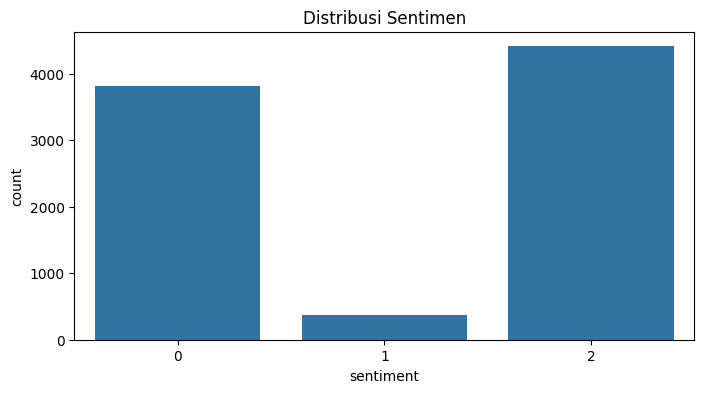

In [ ]:
# Exploratory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(x=df["sentiment"])
plt.title("Distribusi Sentimen")
plt.show()

In [ ]:
# Preprocessing - Membersihkan Teks
from bs4 import BeautifulSoup
import re
import unicodedata
import contractions
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import tqdm

def strip_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    [s.extract() for s in soup(["iframe", "script"])]
    return soup.get_text()

def remove_accented_chars(text):
    return unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8", "ignore")

def remove_stopwords(words):
    stop_words = set(stopwords.words("english"))
    return [w for w in words if w not in stop_words]

def preprocess_text(docs):
    cleaned_docs = []

    for doc in tqdm.tqdm(docs):
        doc = doc.lower()
        doc = strip_html_tags(doc)
        doc = remove_accented_chars(doc)
        doc = contractions.fix(doc)
        doc = re.sub(r"[^a-zA-Z0-9\s]", " ", doc)
        doc = re.sub(r"\s+", " ", doc).strip()

        words = word_tokenize(doc)
        words = remove_stopwords(words)

        cleaned_docs.append(" ".join(words))

    return cleaned_docs

df["news"] = preprocess_text(df["news"])
df.head()

100%|██████████| 8602/8602 [00:03<00:00, 2233.24it/s]


,Dates,URL,news,Price Direction Up,Price Direction Constant,Price Direction Down,Asset Comparision,Past Information,Future Information,sentiment
0,28-01-2016,http://www.marketwatch.com/story/april-gold-do...,april gold 20 cents settle 1 116 10 oz,0,0,1,0,1,0,0
1,13-09-2017,http://www.marketwatch.com/story/gold-prices-s...,gold suffers third straight daily decline,0,0,1,0,1,0,0
2,26-07-2016,http://www.marketwatch.com/story/gold-futures-...,gold futures edge two session decline,1,0,0,0,1,0,2
4,06-09-2017,http://www.marketwatch.com/story/gold-steadies...,gold snaps three day rally trump lawmakers rea...,0,0,1,0,1,0,0
5,16-08-2016,http://www.marketwatch.com/story/dec-gold-clim...,december gold climbs 9 40 0 7 settle 1 356 90 oz,1,0,0,0,1,0,2


In [ ]:
# Tokenisasi
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-uncased")

sentences = df["news"].astype(str).tolist()
labels = df["sentiment"].values

encodings = tokenizer(
    sentences,
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

input_ids = encodings["input_ids"]
attention_mask = encodings["attention_mask"]

input_ids = input_ids.numpy()
attention_mask = attention_mask.numpy()


In [ ]:
# Padding & Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 256

input_ids = pad_sequences(
    input_ids, maxlen=max_len,
    padding="post", truncating="post"
)

attention_masks = [[1 if token > 0 else 0 for token in seq] for seq in input_ids]

In [ ]:
# Split Data
from sklearn.model_selection import train_test_split
import torch

train_input, test_input, train_labels, test_labels = train_test_split(
    input_ids, labels, test_size=0.1, random_state=42
)

train_mask, test_mask, _, _ = train_test_split(
    attention_masks, labels, test_size=0.1, random_state=42
)

train_input, val_input, train_labels, val_labels = train_test_split(
    train_input, train_labels, test_size=0.1, random_state=42
)

train_mask, val_mask, _, _ = train_test_split(
    train_mask, train_mask, test_size=0.1, random_state=42
)

train_input = torch.tensor(train_input)
train_mask = torch.tensor(train_mask)
train_labels = torch.tensor(train_labels)

val_input = torch.tensor(val_input)
val_mask = torch.tensor(val_mask)
val_labels = torch.tensor(val_labels)

test_input = torch.tensor(test_input)
test_mask = torch.tensor(test_mask)
test_labels = torch.tensor(test_labels)

In [ ]:
import numpy as np

validation_input = val_input
validation_labels = val_labels
validation_mask = val_mask

print('---Train---')
print('input: ', train_input.shape)
print('label: ', train_labels.shape)
print('mask:  ', np.array(train_mask).shape)

print('\n---Validation---')
print('input: ', validation_input.shape)
print('label: ', validation_labels.shape)
print('mask:  ', np.array(validation_mask).shape)

print('\n---Test---')
print('input: ', test_input.shape)
print('label: ', test_labels.shape)
print('mask:  ', np.array(test_mask).shape)

---Train---
input:  torch.Size([6966, 256])
label:  torch.Size([6966])
mask:   (6966, 256)

---Validation---
input:  torch.Size([775, 256])
label:  torch.Size([775])
mask:   (775, 256)

---Test---
input:  torch.Size([861, 256])
label:  torch.Size([861])
mask:   (861, 256)


In [ ]:
# Data Loader
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

batch_size = 32

train_data = TensorDataset(train_input, train_mask, train_labels)
train_loader = DataLoader(train_data, sampler=RandomSampler(train_data), batch_size=batch_size)

val_data = TensorDataset(val_input, val_mask, val_labels)
val_loader = DataLoader(val_data, sampler=RandomSampler(val_data), batch_size=batch_size)

test_data = TensorDataset(test_input, test_mask, test_labels)
test_loader = DataLoader(test_data, sampler=RandomSampler(test_data), batch_size=batch_size)

In [ ]:
# Load Model Pretrained BERT
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-multilingual-uncased",
    num_labels=3,
    output_attentions=False,
    output_hidden_states=False
)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [ ]:
# Parameter Info
params = list(model.named_parameters())

print("The BERT model has {:} different named parameters.".format(len(params)))

print("==== Embedding Layer ====")
for p in params[0:5]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("==== First Transformer Layer ====")
for p in params[5:21]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("==== Output Layer ====")
for p in params[-4:]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))

The BERT model has 201 different named parameters.
==== Embedding Layer ====
bert.embeddings.word_embeddings.weight                       (105879, 768)
bert.embeddings.position_embeddings.weight                     (512, 768)
bert.embeddings.token_type_embeddings.weight                     (2, 768)
bert.embeddings.LayerNorm.weight                                   (768,)
bert.embeddings.LayerNorm.bias                                     (768,)
==== First Transformer Layer ====
bert.encoder.layer.0.attention.self.query.weight               (768, 768)
bert.encoder.layer.0.attention.self.query.bias                     (768,)
bert.encoder.layer.0.attention.self.key.weight                 (768, 768)
bert.encoder.layer.0.attention.self.key.bias                       (768,)
bert.encoder.layer.0.attention.self.value.weight               (768, 768)
bert.encoder.layer.0.attention.self.value.bias                     (768,)
bert.encoder.layer.0.attention.output.dense.weight             (768, 768)


In [ ]:
#Optimizer dan Scheduler
from torch.optim import AdamW
from transformers import get_scheduler

optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

epochs = 5

total_steps = len(train_loader) * epochs

scheduler = get_scheduler(
    name="linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

In [ ]:
# Helper Functions (flat_accuracy + format_time)
import numpy as np
import datetime

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [ ]:
# Training
import time
import random
import torch

seed_val = 42
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

loss_values = []

for epoch_i in range(epochs):

    print(f"======= Epoch {epoch_i+1} / {epochs} =======")
    print("Training...")

    t0 = time.time()
    total_loss = 0

    model.train()

    for step, batch in enumerate(train_loader):

        if step % 40 == 0 and step != 0:
            elapsed = format_time(time.time() - t0)
            print(f"Batch {step:>5,} of {len(train_loader):>5,}. Elapsed: {elapsed}")

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()

        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_loss / len(train_loader)
    loss_values.append(avg_train_loss)

    print(f"Average training loss: {avg_train_loss:.2f}")
    print("Training epoch took:", format_time(time.time() - t0))

    # =========================
    #      VALIDATION
    # =========================

    print("\nRunning Validation...")
    t0 = time.time()

    model.eval()

    eval_accuracy = 0
    nb_eval_steps = 0

    for batch in val_loader:
        batch = tuple(t.to(device) for t in batch)

        b_input_ids, b_input_mask, b_labels = batch

        with torch.no_grad():
            outputs = model(
                b_input_ids,
                attention_mask=b_input_mask
            )

        logits = outputs.logits.cpu().numpy()
        label_ids = b_labels.cpu().numpy()

        tmp_accuracy = flat_accuracy(logits, label_ids)
        eval_accuracy += tmp_accuracy
        nb_eval_steps += 1

    print("Accuracy:", eval_accuracy / nb_eval_steps)
    print("Validation took:", format_time(time.time() - t0))

print("Training complete!")

======= Epoch 1 / 5 =======
Training...
Batch    40 of   218. Elapsed: 0:00:47
Batch    80 of   218. Elapsed: 0:01:36
Batch   120 of   218. Elapsed: 0:02:26
Batch   160 of   218. Elapsed: 0:03:17
Batch   200 of   218. Elapsed: 0:04:09
Average training loss: 0.66
Training epoch took: 0:04:32

Running Validation...
Accuracy: 0.8210714285714286
Validation took: 0:00:11
======= Epoch 2 / 5 =======
Training...
Batch    40 of   218. Elapsed: 0:00:51
Batch    80 of   218. Elapsed: 0:01:43
Batch   120 of   218. Elapsed: 0:02:34
Batch   160 of   218. Elapsed: 0:03:26
Batch   200 of   218. Elapsed: 0:04:17
Average training loss: 0.35
Training epoch took: 0:04:41

Running Validation...
Accuracy: 0.8605357142857143
Validation took: 0:00:11
======= Epoch 3 / 5 =======
Training...
Batch    40 of   218. Elapsed: 0:00:51
Batch    80 of   218. Elapsed: 0:01:42
Batch   120 of   218. Elapsed: 0:02:34
Batch   160 of   218. Elapsed: 0:03:26
Batch   200 of   218. Elapsed: 0:04:17
Average training loss: 0.28

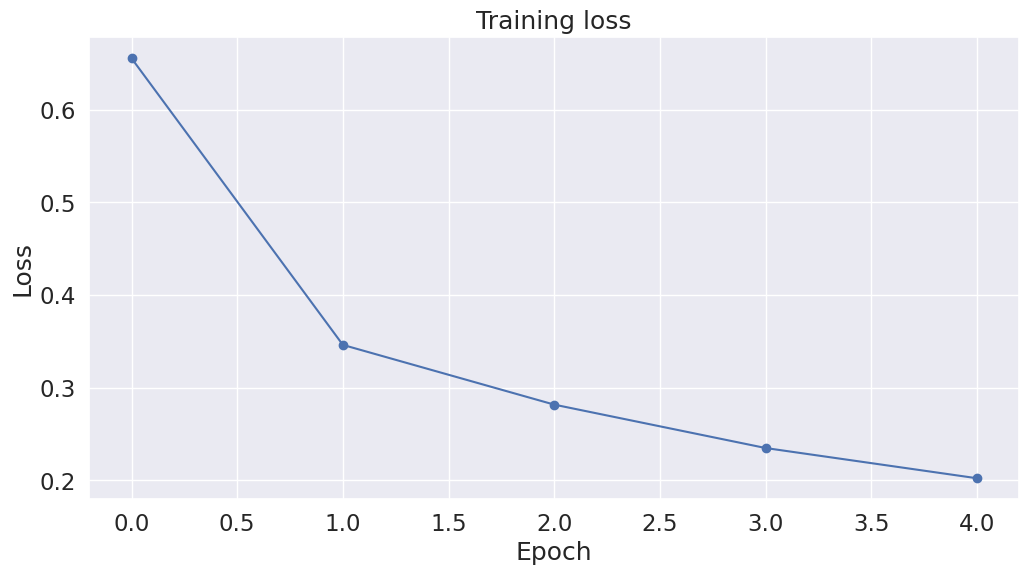

In [ ]:
# Plot Training Loss
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12, 6)

plt.plot(loss_values, 'b-o')
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# Predict test Data
print(f"Predicting labels for {len(test_input):,} test sentences")

model.eval()

prediction = []
true_labels = []

for batch in test_loader:
    batch = tuple(t.to(device) for t in batch)

    b_input_ids, b_input_mask, b_labels = batch

    with torch.no_grad():
        outputs = model(
            b_input_ids,
            attention_mask=b_input_mask
        )

    logits = outputs.logits.cpu().numpy()
    labels = b_labels.cpu().numpy()

    prediction.append(logits)
    true_labels.append(labels)

print("DONE.")

Predicting labels for 861 test sentences
DONE.


In [ ]:
# MCC + Acc
from sklearn.metrics import matthews_corrcoef, accuracy_score

flat_prediction = np.argmax([item for sub in prediction for item in sub], axis=1)
flat_true_labels = [item for sub in true_labels for item in sub]

mcc = matthews_corrcoef(flat_true_labels, flat_prediction)
acc = accuracy_score(flat_true_labels, flat_prediction)

print(f"MCC: {mcc:.3f}")
print(f"ACC: {acc:.3f}")

MCC: 0.753
ACC: 0.870
